# SED Fitting with Bagpipes

Fit the broadband photometry of the AGEL0206 deflector galaxy using [Bagpipes](https://bagpipes.readthedocs.io/) with an exponential-tau star formation history model and Calzetti dust attenuation.

**Filters:** HST F200LP, HST F140W, JWST F150W2, JWST F322W2  
**Redshift prior:** z = 0.674--0.676 (fixed from spectroscopy)  
**Key result:** log(M*/Msun) = 11.34 +0.06/-0.08

In [85]:
import numpy as np 
import bagpipes as pipes
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

from astropy.io import fits
#plt.rcParams['text.usetex'] = True

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams.update({'figure.autolayout': True})


plt.rc('text', usetex=False)
plt.rc('font', family='serif',size=15)
plt.rc('axes', linewidth=1.5) # change back to 1.5
plt.rc('axes', labelsize=20) # change back to 10
plt.rc('xtick', labelsize=22, direction='in')
plt.rc('ytick', labelsize=22, direction='in')
plt.rc('legend', fontsize=15) # change back to 7

# setting xtick parameters:

plt.rc('xtick.major',size=10,pad=4)
plt.rc('xtick.minor',size=5,pad=4)

plt.rc('ytick.major',size=10)
plt.rc('ytick.minor',size=5)


## Convert AB magnitudes to flux density

Convert measured AB magnitudes (with errors) to F_lambda flux density for each filter.

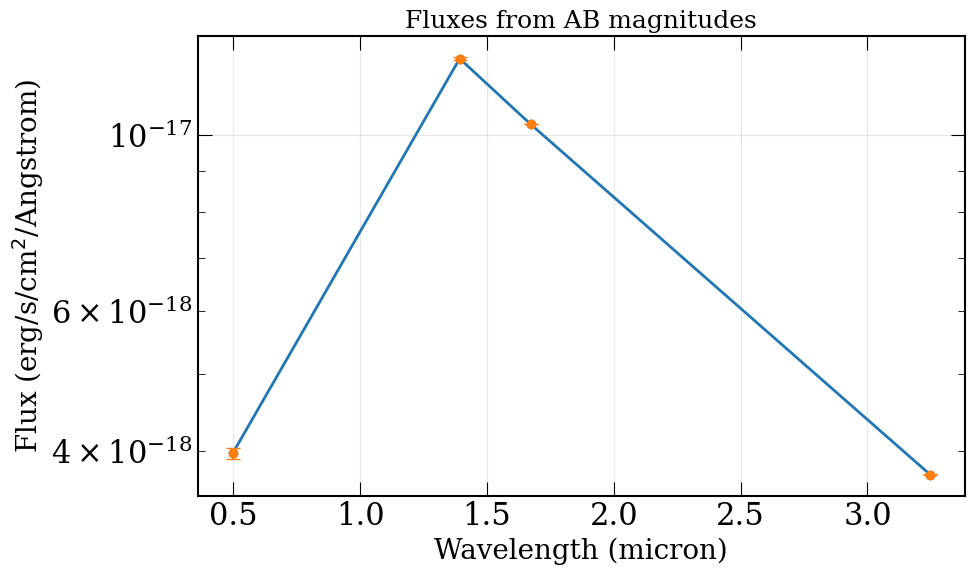

<Quantity [3.96950116e-18, 1.24725443e-17, 1.03121247e-17, 3.73401558e-18] erg / (Angstrom s cm2)>

In [105]:
import astropy.units as u
from astropy.constants import c
abmags= np.array([22.6126,  19.1335, 18.9425, 18.6042 ])*u.ABmag
abmag_errors = np.array([0.0172, 0.0044, 0.0005, 0.0003]) * u.ABmag
filters = ['f200LP', 'f140W', 'f150W2', 'f322W2']
pivot_wavelengths = np.array([4971.9,13923,16720, 32470  ]) * u.AA
#https://hst-docs.stsci.edu/wfc3ihb/chapter-7-ir-imaging-with-wfc3/7-5-ir-spectral-elements
#https://hst-docs.stsci.edu/wfc3ihb/chapter-6-uvis-imaging-with-wfc3/6-5-uvis-spectral-elements
#https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-filters#gsc.tab=0
#

fnu_units = u.erg/u.s/u.Hz/(u.cm**2)
flam_units = u.erg / (u.s * u.cm**2 * u.AA)
fluxes_nu = abmags.to(fnu_units)


fnu_err_upper = ((abmags - abmag_errors).value*u.ABmag).to(fnu_units) - fluxes_nu 
fnu_err_lower = fluxes_nu - ((abmags - abmag_errors).value*u.ABmag).to(fnu_units)


fluxes_lambda = (fluxes_nu * (c / pivot_wavelengths**2)).to(flam_units)
flam_err_upper = (fnu_err_upper * (c / pivot_wavelengths**2)).to(flam_units)
flam_err_lower = (fnu_err_lower * (c / pivot_wavelengths**2)).to(flam_units)

fluxes_lambda_error = np.maximum(flam_err_upper, flam_err_lower)

#wavelengths = np.array([0.2, 1.4, 1.5, 3.22]) * u.micron
#fluxes = abmags.to(u.erg / (u.s * u.cm**2 * u.Hz))

plt.figure(figsize=(10,6))
plt.plot(pivot_wavelengths.to(u.micron), fluxes_lambda, 'o-')
plt.errorbar(pivot_wavelengths.to(u.micron), fluxes_lambda, yerr=fluxes_lambda_error, fmt='o', capsize=5)
plt.xscale(r'linear')
plt.yscale(r'log')
plt.xlabel(r'Wavelength (micron)')
plt.ylabel(r'Flux (erg/s/cm$^2$/Angstrom)')
plt.title(r'Fluxes from AB magnitudes')
plt.grid(True, alpha=0.3)
plt.show()
fluxes_lambda

In [ ]:
fluxes_lambda_error/fluxes_lambda # Sub 2% errors

<Quantity [0.01596793, 0.00406077, 0.00046062, 0.00027635]>

## Load filter transmission curves

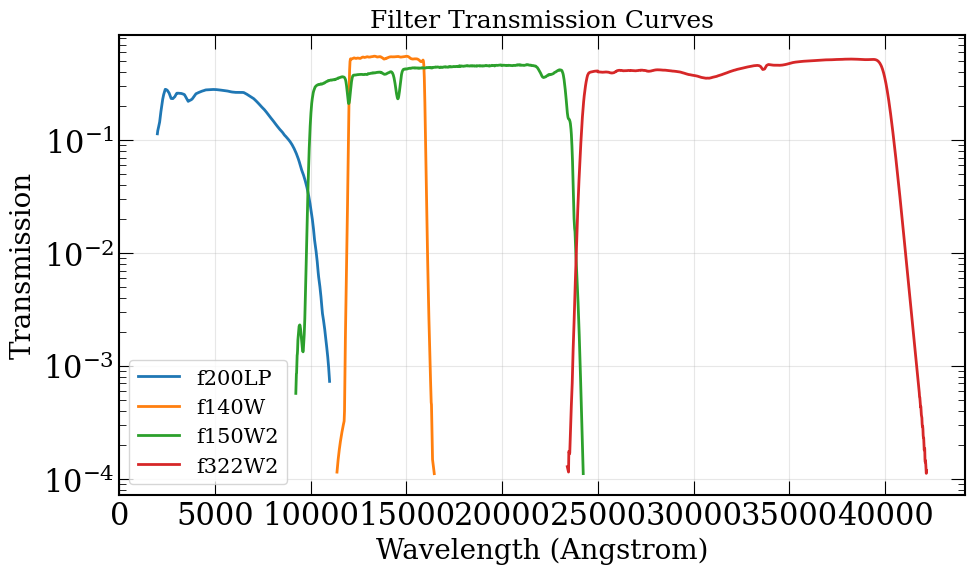

In [106]:
from astropy.io import fits, ascii

hst200 = ascii.read('HST_WFC3_UVIS1.F200LP.dat')
hst140 = ascii.read('HST_WFC3_IR.F140W.dat')
jwst150 = ascii.read('JWST_NIRCam.F150W2.dat')
jwst322 = ascii.read('JWST_NIRCAM.F322W2.dat')
filters = [hst200, hst140, jwst150, jwst322]
filter_names = ['f200LP', 'f140W', 'f150W2', 'f322W2']
plt.figure(figsize=(10,6))
for i, filt in enumerate(filters):
    plt.plot(filt['col1'], filt['col2'], label=filter_names[i])
plt.xscale(r'linear')
plt.yscale(r'log')
plt.xlabel(r'Wavelength (Angstrom)')
plt.ylabel(r'Transmission')
plt.title(r'Filter Transmission Curves')
plt.grid(True, alpha=0.3)
plt.legend()

## Set up Bagpipes galaxy object

Define the `load_data` function that returns the photometry array, and create the Bagpipes galaxy object with the filter list.

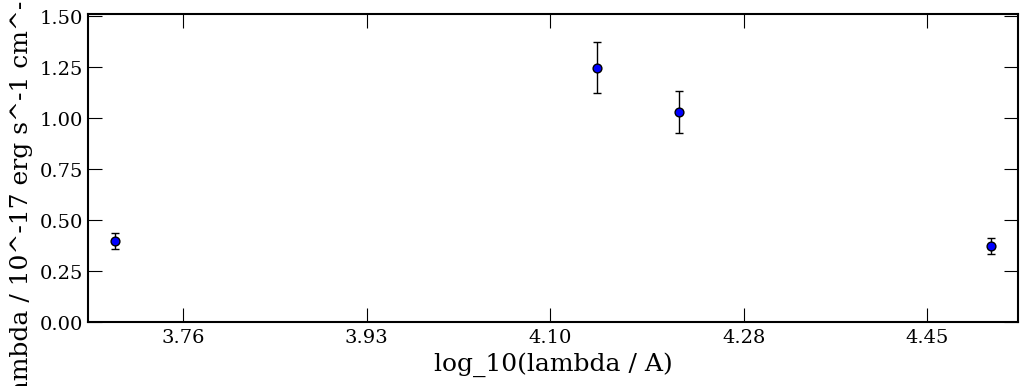

In [180]:
from astropy.table import Table
IDs = ['AGEL0206']


fluxes_lambda_error = np.array([0.1, 0.01, 0.05, 0.05]) * fluxes_lambda

fluxes_lambda_error_wide = np.array([0.2, 0.01, 0.1, 0.1]) * fluxes_lambda

fluxes_lambda_error_realistic = np.array([0.05, 0.05, 0.05, 0.05]) * fluxes_lambda

fluxes_lambda_error_realistic = np.array([0.1, 0.1, 0.1, 0.1]) * fluxes_lambda

#fluxes_lambda_error_realistic = np.array([0.2, 0.2, 0.2, 0.2]) * fluxes_lambda

def load_data(ID):
    ID_ = ID
    photometry = np.array([fluxes_lambda, fluxes_lambda_error_realistic]).T

    return photometry



filt_list = ['HST_WFC3_UVIS1.F200LP.dat', 'HST_WFC3_IR.F140W.dat', 'JWST_NIRCam.F150W2.dat', 'JWST_NIRCAM.F322W2.dat']

galaxy = pipes.galaxy("0206_real", load_data, spectrum_exists=False, filt_list=filt_list, phot_units='ergscma')

fig = galaxy.plot()
# fig[1][0].set_yscale('log')  
# fig[1][0].set_ylim(1e-18, 1e-15)
# plt.show()

## Model specification: exponential-tau SFH + Calzetti dust

Define the SED model with free parameters for age, tau, stellar mass formed, metallicity, dust attenuation (Av), and redshift.

In [181]:
exp = {}                                  # Tau-model star-formation history component
exp["age"] = (0.1, 15.)                   # Vary age between 100 Myr and 15 Gyr. In practice 
                                          # the code automatically limits this to the age of
                                          # the Universe at the observed redshift.

exp["tau"] = (0.3, 10.)                   # Vary tau between 300 Myr and 10 Gyr
exp["massformed"] = (1., 15.)             # vary log_10(M*/M_solar) between 1 and 15
exp["metallicity"] = (0., 2.5)            # vary Z between 0 and 2.5 Z_oldsolar

dust = {}                                 # Dust component
dust["type"] = "Calzetti"                 # Define the shape of the attenuation curve
dust["Av"] = (0., 2.)                     # Vary Av between 0 and 2 magnitudes

fit_instructions = {}                     # The fit instructions dictionary
fit_instructions["redshift"] = (0.674, 0.676)  # Vary observed redshift from 0 to 10
fit_instructions["exponential"] = exp   
fit_instructions["dust"] = dust

## Run the fit (MultiNest / Nautilus)

Execute the Bagpipes fitting. Results are cached in `pipes/posterior/` as HDF5 files.

In [182]:
import ctypes
import os

import ctypes.util

# Try to fix the MultiNest library linking issue on macOS
multinest_lib = ctypes.util.find_library('multinest')
if multinest_lib:
    ctypes.CDLL(multinest_lib, mode=ctypes.RTLD_GLOBAL)

# Alternative: set the sampler explicitly and retry the fit
fit = pipes.fit(galaxy, fit_instructions, run="AGEL0206")

try:
    fit.fit(verbose=True, sampler="multinest", n_live=400)
except AttributeError as e:
    print(f"Error: {e}")
    print("Trying with nautilus sampler...")
    fit.fit(verbose=True, sampler="nautilus", n_live=400)


Results loaded from pipes/posterior/AGEL0206/0206_real.h5

Fitting not performed as results have already been loaded from pipes/posterior/AGEL0206/0206_real.h5. To start over delete this file or change run.



## Posterior results

Extract stellar mass, SFR, mass-weighted age, and other derived quantities from the posterior samples.

In [183]:
list(fit.posterior.samples)

['dust:Av',
 'exponential:age',
 'exponential:massformed',
 'exponential:metallicity',
 'exponential:tau',
 'redshift',
 'stellar_mass',
 'formed_mass',
 'sfr',
 'ssfr',
 'nsfr',
 'mass_weighted_age',
 'tform',
 'tquench',
 'mass_weighted_zmet',
 'sfh']

In [184]:
median_Mstellar = np.median(fit.posterior.samples["stellar_mass"])

sigma_Mstellar = np.abs(median_Mstellar - np.percentile(fit.posterior.samples["stellar_mass"], [16, 84]))
print(f"Median stellar mass: {median_Mstellar:.2f} + {sigma_Mstellar[1]:.2f} - {sigma_Mstellar[0]:.2f} M_sun")

Median stellar mass: 11.34 + 0.06 - 0.08 M_sun


In [185]:
print(np.median(np.log10(fit.posterior.samples["sfr"]) - fit.posterior.samples["stellar_mass"]))

-11.992739384291486


In [186]:
print(np.percentile(fit.posterior.samples["mass_weighted_age"], (16, 84)))

[3.83470634 6.0240803 ]


In [187]:
fit.posterior.get_advanced_quantities()
list(fit.posterior.samples)

['dust:Av',
 'exponential:age',
 'exponential:massformed',
 'exponential:metallicity',
 'exponential:tau',
 'redshift',
 'stellar_mass',
 'formed_mass',
 'sfr',
 'ssfr',
 'nsfr',
 'mass_weighted_age',
 'tform',
 'tquench',
 'mass_weighted_zmet',
 'sfh',
 'photometry',
 'spectrum_full',
 'uvj',
 'chisq_phot',
 'dust_curve']

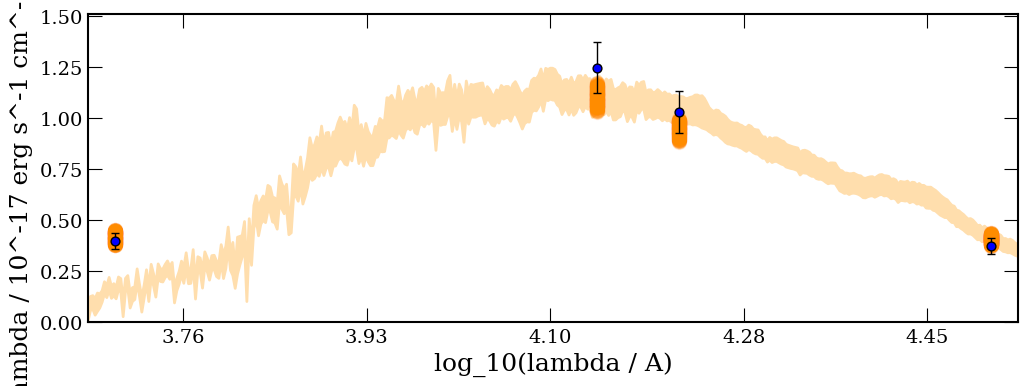

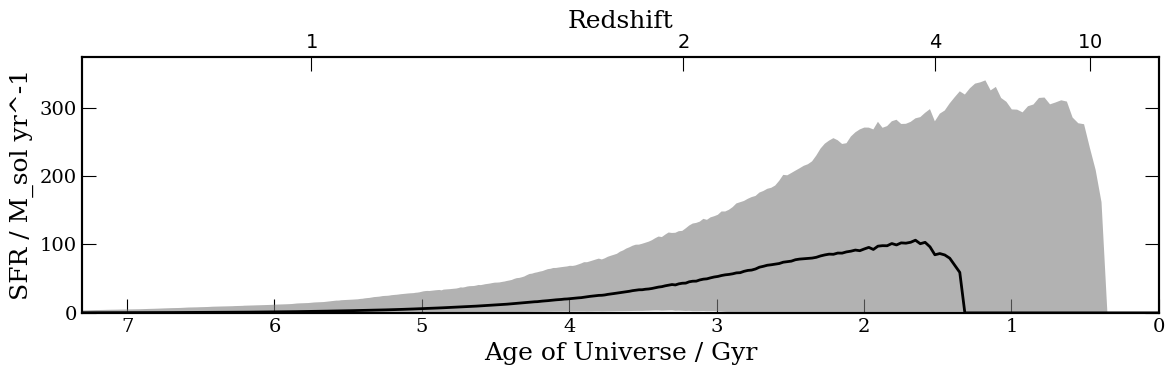

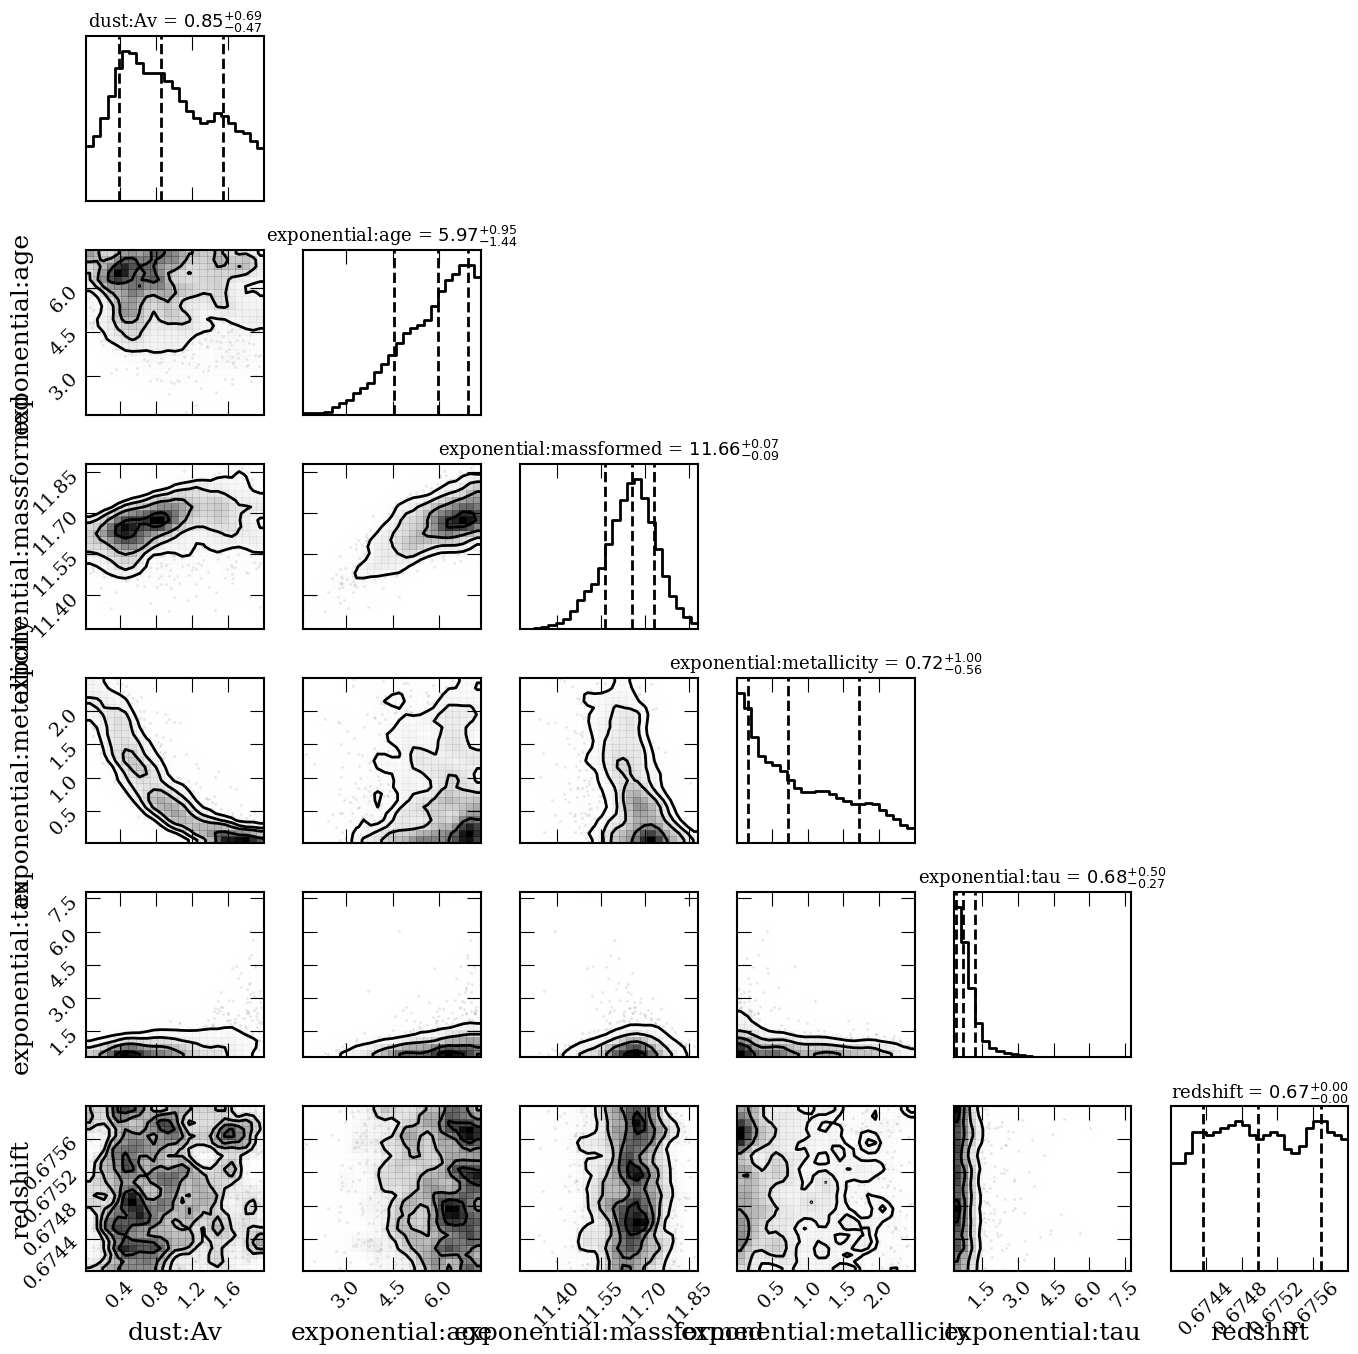

In [188]:

fig = fit.plot_spectrum_posterior(save=False, show=True)
fig = fit.plot_sfh_posterior(save=False, show=True)
fig = fit.plot_corner(save=False, show=True)

/opt/anaconda3/envs/prospector/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


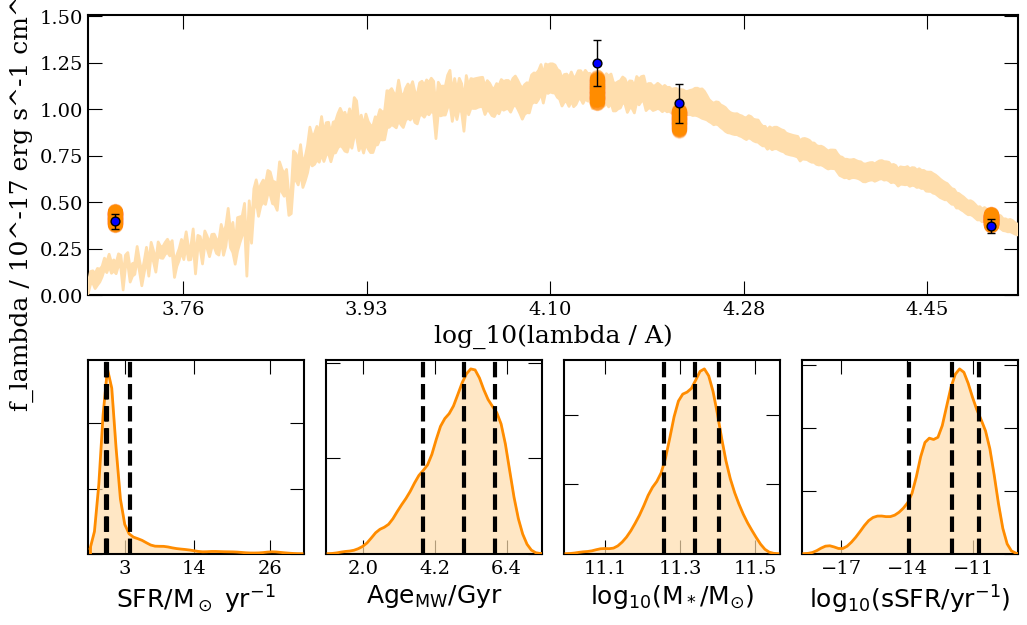

In [189]:
plt.close()

fig = plt.figure(figsize=(12, 7))
gs = mpl.gridspec.GridSpec(7, 4, hspace=3., wspace=0.1)

ax1 = plt.subplot(gs[:4, :])

pipes.plotting.add_observed_photometry(fit.galaxy, ax1, zorder=10)
pipes.plotting.add_photometry_posterior(fit, ax1)




labels = ["sfr", "mass_weighted_age", "stellar_mass", "ssfr"]

post_quantities = dict(zip(labels, [fit.posterior.samples[l] for l in labels]))

axes = []
for i in range(4):
    axes.append(plt.subplot(gs[4:, i]))
    pipes.plotting.hist1d(post_quantities[labels[i]], axes[-1], smooth=True, label=labels[i])

plt.show()